In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft
from scipy.signal import fftconvolve
from scipy.optimize import curve_fit
from scipy.stats import norm
import functions as f
import matplotlibcolors as matplotlibcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
plt.style.use('matplotlibrc')

%matplotlib widget

In [5]:
kid = 5
pread = 113
file_type = 'vis'
pw = 1500
pw_offset = 100
filter_type = 'exp'
lifetime = 236
tqp = [200, 600]
iterate = 0

dir_on = r"D:\Data\LT218Chip1_BF_20240116_MIR18_5\KID5_all_temps\200K"
dir_off = r"D:\Data\LT218Chip1_BF_20240116_MIR18_5\KID5_all_temps\100K"
chuncksize = 20
nr_chuncks = 1
mph = np.array([5, 40])
mpp = mph[0]


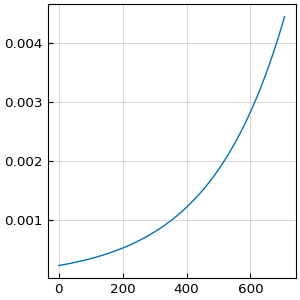

In [6]:
pulse_files, info_files = f.get_files(dir_on, kid, pread, type=file_type)
nr_files = len(pulse_files)
f0, Q, Qc, Qi, S21_min, dt, T = f.get_info(info_files[0])
sff = 1 / dt / 1e6
sw = int(lifetime * sff)
exp_filter = f.get_window(filter_type, sw)
fig, ax = plt.subplots(figsize=(3,3),constrained_layout=True)
ax.plot(exp_filter)

In [7]:
amp, phase, _ = f.get_data(pulse_files[:chuncksize])
signal = f.coord_transformation(phase, amp, coord='circle', response='phase')

In [8]:
std = f.get_sigma(signal, exp_filter)
ph = mph*std
pp = mpp*std
locs, props = f.find_pks(signal, ph[0], pp, exp_filter)
too_high_chunck = props['peak_heights'] >= ph[1]
args = np.argwhere(~too_high_chunck).flatten()
pulses, single_idx = f.get_single_pulses(signal, locs, pw, pw_offset, args)
pulse_template = np.mean(pulses, axis=0)

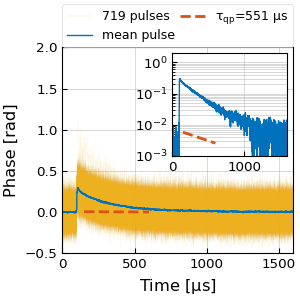

In [9]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, pulses.T, alpha=.2, lw=.1, c='y', label='_nolegend_')
ax.plot(t, pulses[0], lw=.1, c='y', label='%d pulses' % len(pulses))
ax.plot(t, pulse_template, label='mean pulse')
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
_ = ax.legend()

fit_tqp = [150,600]    
tqp, _, popt = f.fit_decaytime(pulse_template, pw, fit_tqp)
tqp /= sff
tqp_x = np.linspace(fit_tqp[0]/sff, fit_tqp[1]/sff, int((fit_tqp[1] - fit_tqp[0])))
fit_x = np.arange(len(tqp_x))
tqp_y = f.exp_decay(fit_x, *popt)
ax.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=2, mode="expand", borderaxespad=0., fontsize=9)
# BEGIN: Add inset with semilogy axes

ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right')
ax_inset.plot(t, pulse_template, label='mean pulse')
ax_inset.set_xlim([t[0], t[-1]])
ax_inset.set_ylim([1e-3, 2])
ax_inset.set_yscale('log')
# ax_inset.set_xlabel('Time [$\mu$s]')
# ax_inset.set_ylabel('Phase [rad]')
ax_inset.plot(tqp_x, tqp_y, ls='--', lw=2, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)
# END: Add inset with semilogy axes

In [10]:
noise_files, _ = f.get_files(dir_off, kid, pread, type=file_type)
amp, phase, _ = f.get_data(noise_files[:chuncksize])
noise = f.coord_transformation(phase, amp, coord='circle', response='phase')

In [11]:
std = f.get_sigma(noise, exp_filter)
ph = 6*std
pp = ph
noise_locs, _ = f.find_pks(noise, ph, pp, exp_filter)
noises = f.get_single_noises(noise, noise_locs, pw+pw_offset)
_, noise_psd = f.get_avg_psd(noises, pw+pw_offset, sff, exclude_dc=False, onesided=False)

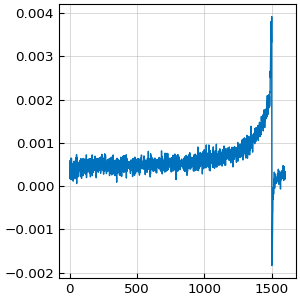

In [12]:
def opt_filter(mean_pulse, noise_psd, exclude_dc=True):      
    """
    optimal_filter computes the optimal filter that needs to be uploaded to the mux
    :param norm_pulse_fft:  numpy.ndarray, 1D complex array of pulse model
    :param noise_psd:       numpy.ndarray, 1D complex array of noise model
    :param exclude_dc:      bool, whether to exclude the DC value of the fft
    :return filter:         numpy.ndarray, 1D comlex array of normalised optimal filter
    """
    norm_pulse = mean_pulse / np.amax(mean_pulse)
    norm_pulse_fft = fft(norm_pulse)
    filter = norm_pulse_fft.conj()/noise_psd
    return ifft(filter)

opt_filter = f.opt_filter(pulse_template, noise_psd, exclude_dc=False).real
opt_filter /= np.sum(opt_filter)
fig, ax = plt.subplots(constrained_layout=True, figsize=(3,3))
ax.plot(opt_filter)

(-0.2, 0.5)

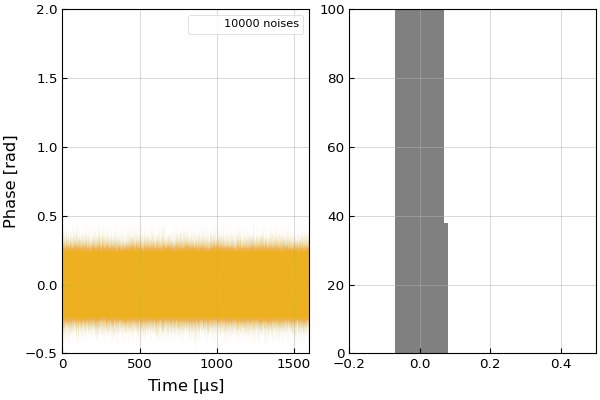

In [13]:
fig, axes = plt.subplot_mosaic('ab', constrained_layout=True, figsize=(6,4))
ax = axes['a']
t = np.arange(0, pw+pw_offset, 1)
ax.plot(t, noises[::10].T, alpha=.1, lw=.1, c='y')
ax.plot(t, noises[0], alpha=.1, lw=.1, c='y', label='%d noises' % len(noises))
# ax.plot(t, pulse_template)
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
ax.legend(loc='upper right')
ax = axes['b']
binsize = 0.01
bins=np.arange(-.5, 2, binsize)
_ = ax.hist(fftconvolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='0 $\sigma$')
ax.set_ylim([0,100])
ax.set_xlim([-.2,.5])

In [14]:
def get_pulses(pulse_files, ph, pp, pw, pw_offset, chuncksize, nr_chuncks, window):
    if nr_chuncks:
        nr_req_files = np.amin((chuncksize * nr_chuncks, nr_files))
    else:
        nr_req_files = nr_files
    analysed_files = 0
    pulses = []
    single_idx = []
    too_high_idx = []
    single_locs = []
    while analysed_files < nr_req_files:
        if analysed_files + chuncksize > nr_files:
            chuncksize = nr_files - analysed_files
        amp, phase, _ = f.get_data(pulse_files[analysed_files:analysed_files+chuncksize])
        signal = f.coord_transformation(phase, amp, coord='circle', response='phase')
        len_file = int(len(signal) / chuncksize)
        locs, props = f.find_pks(signal, ph, pp, window)
        # too_high_chunck = props['peak_heights'] >= ph[1]
        args = np.argwhere(~too_high_chunck).flatten()
        args = np.arange(len(locs), dtype=int)
        pulses_chunck, single_idx_chunck = f.get_single_pulses(signal, locs, pw, pw_offset, args)
        if len(pulses_chunck):
            pulses.append(pulses_chunck)
            single_idx.append(single_idx_chunck)
            too_high_idx.append(too_high_chunck)
            single_locs.append(locs[single_idx_chunck] + len_file*analysed_files)
        analysed_files += chuncksize
        print('Analysed %d out of %d files' % (analysed_files, nr_req_files), end='\r')
    single_idx = np.hstack(single_idx)
    pulses = np.vstack(pulses)
    too_high_idx = np.hstack(too_high_idx)
    single_locs = np.hstack(single_locs)
    return pulses, single_idx, too_high_idx, single_locs


In [15]:
std = f.get_sigma(noise, exp_filter)
nr_stds = [3,4,5]
H_opts = []
nr_chuncks = [None, None, None, None]
for i, nr_std in enumerate(nr_stds):
    ph = nr_std * std
    pp = nr_std * std
    pulses, _, _, _ = get_pulses(pulse_files, ph, pp, pw, pw_offset, 20, nr_chuncks[i], exp_filter)
    H_opt, R_sn, _, _ = f.optimal_filter(pulses, pulse_template, sff*1e6, 1, noise_psd)
    H_opts.append(H_opt)

Resolving power could not accurately be determined
2.740653412207614


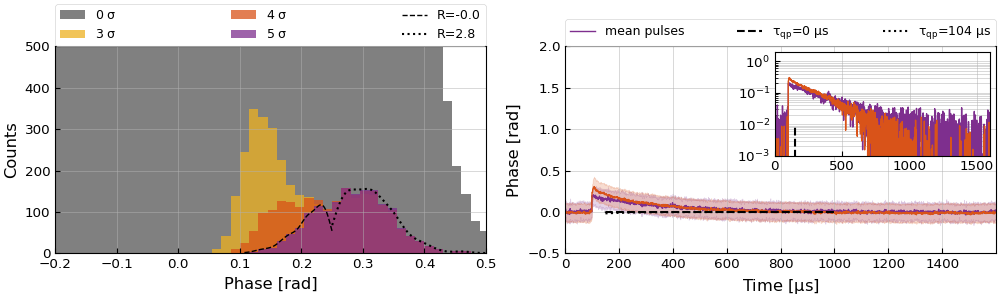

In [20]:
fig, axes = plt.subplot_mosaic('ab', constrained_layout=True, figsize=(10,3))
ax = axes['a']
binsize = 0.015
bins=np.arange(-.5, 2, binsize)
# ax.hist(fftconvolve(noises.flatten(), opt_filter, mode='valid'), bins=bins, facecolor='gray', label='0 $\sigma$')
ax.hist(noises.flatten(), bins=bins, facecolor='gray', label='0 $\sigma$')
colors = ['y', 'o','p'] 
for i, H_opt in enumerate(H_opts):
    _ = ax.hist(H_opt, bins=bins, facecolor=colors[i],alpha=.75, label='%d $\sigma$' % (nr_stds[i]))

ax.set_ylim([0, 500])
ax.set_xlim([-.2,.5])
ax.set_ylabel('Counts')
ax.set_xlabel('Phase [rad]')
sel_idx = H_opt < .25
sel_H = H_opt[sel_idx]
sel_pulses = pulses[sel_idx]
mean_pulse = np.mean(sel_pulses, axis=0) 
std_pulse = np.std(sel_pulses, axis=0)  
outliers = np.any(sel_pulses > (mean_pulse + 3*std_pulse), axis=1)
R_opt, pdf_y, pdf_x, _, _ = f.resolving_power(sel_H, binsize)
ax.plot(pdf_x, pdf_y, c='k', ls='--', label='R=%.1f' % (R_opt))
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0., fontsize=9)
sel_pulses = sel_pulses[~outliers]
mean_pulse = np.mean(sel_pulses, axis=0)
std_pulse = np.std(sel_pulses, axis=0)
sel_H = sel_H[~outliers]

ax = axes['b']
t = np.arange(0, pw+pw_offset, 1)
# ax.plot(t, sel_pulses.T, alpha=.1, lw=.1, c=colors[-1], label='_nolegend_')
# ax.plot([], [], lw=1, c=colors[-1], label='6 $\sigma$ pulses', alpha=1)
ax.plot(t, np.mean(sel_pulses, axis=0), c='p', label='mean pulses')
ax.fill_between(t, mean_pulse - std_pulse, mean_pulse + std_pulse, color=colors[-1], alpha=.2)

fit_tqp = [150,1000]    
tqp, _, popt = f.fit_decaytime(mean_pulse, pw, fit_tqp)
tqp /= sff
tqp_x = np.linspace(fit_tqp[0]/sff, fit_tqp[1]/sff, int((fit_tqp[1] - fit_tqp[0])))
fit_x = np.arange(len(tqp_x))
tqp_y = f.exp_decay(fit_x, *popt)
ax.plot(tqp_x, tqp_y, c='k', ls='--', lw=1.5, label='$\\tau_{qp}$=%d $\mu$s' % tqp, zorder=3)

ax_inset = inset_axes(ax, width="50%", height="50%", loc='upper right')
ax_inset.semilogy(t, mean_pulse, c='p', label='mean pulse')
ax_inset.semilogy(tqp_x, tqp_y, c='k', ls='--', lw=1.5)
ax_inset.set_xlim([t[0], t[-1]])
ax_inset.set_ylim([1e-3, 2])

ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=2, mode="expand", borderaxespad=0., fontsize=9)
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.2, .5])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')

ax = axes['a']
sel_idx = (H_opt >= .25)
sel_H = H_opt[sel_idx]
sel_pulses = pulses[sel_idx]
mean_pulse = np.mean(sel_pulses, axis=0) 
std_pulse = np.std(sel_pulses, axis=0)  
outliers = np.any(sel_pulses > (mean_pulse + 3*std_pulse), axis=1)
R_opt, pdf_y, pdf_x, _, _ = f.resolving_power(sel_H, binsize)
ax.plot(pdf_x, pdf_y, c='k', ls=':', label='R=%.1f' % (R_opt), lw=1.5)
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0., fontsize=9)
sel_pulses = sel_pulses[~outliers]
mean_pulse = np.mean(sel_pulses, axis=0)
sel_H = sel_H[~outliers]

ax = axes['b']
# ax.plot(t, sel_pulses.T, alpha=.1, lw=.1, c=colors[-1], label='_nolegend_')
ax.plot(t, mean_pulse, c='o')
ax.fill_between(t, mean_pulse - std_pulse, mean_pulse + std_pulse, color='o', alpha=.2)
  
tqp, dtqp, popt = f.fit_decaytime(mean_pulse, pw, fit_tqp)
tqp_y = f.exp_decay(fit_x, *popt)
ax.plot(tqp_x, tqp_y, c='k', ls=':', lw=1.5, label='$\\tau_{qp}$=%d $\mu$s' % (tqp), zorder=3)
ax_inset.semilogy(t, mean_pulse, c='o')
ax_inset.semilogy(tqp_x, tqp_y, c='k', ls=':', lw=1.5)
ax_inset.set_xlim([t[0], t[-1]])
ax_inset.set_ylim([1e-3, 2])
ax.legend(bbox_to_anchor=(0., 1, 1., .102), loc='lower left',
        ncols=3, mode="expand", borderaxespad=0., fontsize=9)
ax.set_xlim([t[0], t[-1]])
ax.set_ylim([-.5, 2])
ax.set_xlabel('Time [$\mu$s]')
ax.set_ylabel('Phase [rad]')
# plt.savefig('resolving power 185um.pdf')
print(R_sn)
# axes['a'].hist(signal.flatten(), bins=1000, facecolor='gray', label='0 $\sigma$')


[ 0.12217439  0.02575171 19.18794173  0.24751976  0.09601864 14.22954945]
4.744321132154162
2.577830336904202
[4.92201871e-04 6.79805913e-04 7.14691578e-01 8.30712640e-03
 7.16610147e-03 1.04192563e+00]


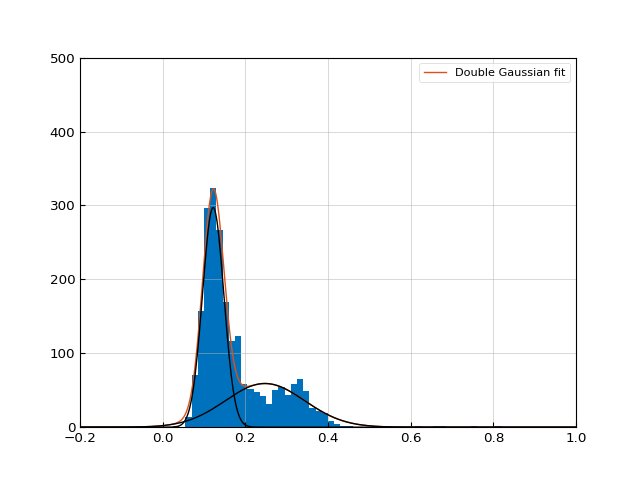

In [29]:
fig, ax = plt.subplots()
binsize = 0.015
bins=np.arange(-.5, 2, binsize)
ax.hist(H_opt, bins=bins, density=False)
# Define a double Gaussian function
def double_gaussian(x, mu1, sigma1, A1, mu2, sigma2, A2):
    return A1 * norm.pdf(x, mu1, sigma1) + A2 * norm.pdf(x, mu2, sigma2)

def single_gaussian(x, mu1, sigma1, A1):
    return A1 * norm.pdf(x, mu1, sigma1)

# Histogram data
hist, bin_edges = np.histogram(H_opt, bins=bins, density=False)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Initial guess for the parameters
initial_guess = [.12, .1, 450, .32, .1, 100]

# Fit the double Gaussian model to the histogram data
popt, pcov = curve_fit(double_gaussian, bin_centers, hist, p0=initial_guess)

# Plot the fitted double Gaussian
x_fit = np.linspace(bin_edges[0], bin_edges[-1], 1000)
y_fit = double_gaussian(x_fit, *popt)
ax.plot(x_fit, y_fit, label='Double Gaussian fit')
ax.plot(x_fit, single_gaussian(x_fit, *popt[:3]), c='k')
ax.plot(x_fit, single_gaussian(x_fit, *popt[3:]), c='k')
ax.set_ylim([0, 500])
ax.set_xlim([-.2, 1])
ax.legend()
print(popt)
print(popt[0]/popt[1])
print(popt[3]/popt[4])
print(np.sqrt(np.diag(pcov)))